1. Install Dependencies in Notebook Runtime

In [21]:
# Uncomment in a fresh Colab or notebook runtime.
# %pip install -q "numpy<2" unsloth trl datasets bitsandbytes transformers torch httpx matplotlib python-dotenv openenv jupytext nbformat

import sys
import subprocess

print('Install the required packages above before running the remaining cells.')

Install the required packages above before running the remaining cells.


2. Set Configuration and Runtime Paths

In [22]:

import torch

ENV_URL = "http://localhost:7860"  # Replace if using remote env
BENCHMARK = "officeagentenv"
TASK = "medium"
MAX_EPISODES = 3
STEPS_PER_EPISODE = 15

BASE_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
SMOKE_TEST_MODEL_NAME = "sshleifer/tiny-gpt2"
if not torch.cuda.is_available():
    BASE_MODEL_NAME = SMOKE_TEST_MODEL_NAME
OUTPUT_DIR = "/content/officeagent-ft"

BATCH_SIZE = 2 if torch.cuda.is_available() else 1
EPOCHS = 2 if torch.cuda.is_available() else 1
LEARNING_RATE = 2e-4
MAX_SEQ_LENGTH = 2048 if torch.cuda.is_available() else 256

print({
    "ENV_URL": ENV_URL,
    "BENCHMARK": BENCHMARK,
    "TASK": TASK,
    "MAX_EPISODES": MAX_EPISODES,
    "STEPS_PER_EPISODE": STEPS_PER_EPISODE,
    "BASE_MODEL_NAME": BASE_MODEL_NAME,
    "OUTPUT_DIR": OUTPUT_DIR,
})

{'ENV_URL': 'http://localhost:7860', 'BENCHMARK': 'officeagentenv', 'TASK': 'medium', 'MAX_EPISODES': 3, 'STEPS_PER_EPISODE': 15, 'BASE_MODEL_NAME': 'sshleifer/tiny-gpt2', 'OUTPUT_DIR': '/content/officeagent-ft'}


3. Import Libraries and Validate GPU


In [23]:
import os
import time
from typing import Any, Dict, List

import httpx
import matplotlib.pyplot as plt
import torch
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

print(f"torch: {torch.__version__}")
print(f"cuda_available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"cuda_device: {torch.cuda.get_device_name(0)}")
    print(f"cuda_capability: {torch.cuda.get_device_capability(0)}")
    print(f"default_dtype: {torch.float16}")
else:
    print("Running on CPU; training will be slow.")

torch: 2.11.0+cpu
cuda_available: False
Running on CPU; training will be slow.


4. Define Environment API Helpers (reset, step)


In [48]:
def env_reset(seed: int = 42) -> Dict[str, Any]:
    try:
        response = httpx.post(
            f"{ENV_URL}/reset",
            json={"task": TASK, "seed": seed},
            timeout=30,
        )
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, dict):
            raise ValueError("reset payload must be a dict")
        # /reset returns {'observation': ..., 'reward': 0, ...}; return the inner observation.
        observation = payload.get("observation", payload)
        if not isinstance(observation, dict):
            raise ValueError("reset observation must be a dict")
        return observation
    except Exception as exc:
        print(f"[ERROR] Reset failed: {exc}")
        return {}


def env_step(action: Dict[str, Any]) -> Dict[str, Any]:
    try:
        response = httpx.post(f"{ENV_URL}/step", json=action, timeout=30)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, dict):
            raise ValueError("step payload must be a dict")
        # Keep step payload intact (contains reward/done/observation/info).
        return payload
    except Exception as exc:
        print(f"[ERROR] Step failed: {exc}")
        return {"done": True, "reward": -1.0, "error": str(exc), "observation": {}}

print("Environment helpers ready.")

Environment helpers ready.


5. Format Observation/Action Text and Heuristic Policy


In [49]:

def format_observation_as_text(obs: Dict[str, Any]) -> str:
    text_parts: List[str] = []
    if obs.get("pending_emails"):
        text_parts.append("PENDING EMAILS:")
        for idx, email in enumerate(obs["pending_emails"][:5], start=1):
            text_parts.append(
                f"  {idx}. From: {email.get('sender', '')}, Subject: {email.get('subject', '')}"
            )
    if obs.get("calendar_events"):
        text_parts.append("\nCALENDAR EVENTS:")
        for event in obs["calendar_events"][:3]:
            text_parts.append(f"  - {event.get('title', '')} at {event.get('start_time', '')}")
    if "current_step" in obs:
        text_parts.append(f"\nCurrent Step: {obs['current_step']}")
    return "\n".join(text_parts)


def format_action_as_text(action: Dict[str, Any]) -> str:
    action_type = action.get("action_type", "unknown")
    email_id = action.get("email_id", "")
    if action_type == "classify_email":
        return f"CLASSIFY email {email_id} as {action.get('category', '')}"
    if action_type == "reply_email":
        return f"REPLY to email {email_id}: {action.get('reply_text', '')[:100]}..."
    if action_type == "schedule_meeting":
        return f"SCHEDULE meeting '{action.get('meeting_title', '')}' at {action.get('meeting_start_time', '')}"
    if action_type == "ignore_email":
        return f"IGNORE email {email_id}"
    return f"ACTION: {action_type}"


def heuristic_action(obs: Dict[str, Any]) -> Dict[str, Any]:
    pending = obs.get("pending_emails", [])
    if not pending:
        return {"action_type": "ignore_email", "email_id": "none"}
    email = pending[0]
    # API payloads use `email_id`; keep a safe fallback for older keys.
    email_id = email.get("email_id") or email.get("id") or "0"
    return {
        "action_type": "classify_email",
        "email_id": email_id,
        "category": "meeting_request",
    }

print("Formatting helpers and heuristic policy ready.")

Formatting helpers and heuristic policy ready.


6. Collect Trajectories from OfficeAgentEnv


In [55]:
trajectories: List[Dict[str, Any]] = []
reward_history: List[float] = []

print("[STEP 1] Collecting trajectories...")
for episode_idx in range(1, MAX_EPISODES + 1):
    obs = env_reset(seed=42 + episode_idx)
    if not obs:
        continue

    trajectory = {"episode": episode_idx, "steps": [], "total_reward": 0.0}
    cumulative_reward = 0.0

    for step_idx in range(STEPS_PER_EPISODE):
        obs_text = format_observation_as_text(obs)
        action = heuristic_action(obs)
        action_text = format_action_as_text(action)

        step_result = env_step(action)
        reward = float(step_result.get("reward", -1.0))
        done = bool(step_result.get("done", False))
        cumulative_reward += reward

        trajectory["steps"].append(
            {
                "observation": obs_text,
                "action": action_text,
                "action_dict": action,
                "reward": reward,
                "done": done,
            }
        )

        print(f"  Episode {episode_idx}, Step {step_idx + 1}: reward={reward:.2f}")
        if done:
            break
        obs = step_result.get("observation", obs)

    trajectory["total_reward"] = cumulative_reward
    trajectories.append(trajectory)
    reward_history.append(cumulative_reward)
    time.sleep(0.3)

avg_reward = sum(reward_history) / len(reward_history) if reward_history else 0.0
print(f"[SUMMARY] Episodes: {len(trajectories)}, Avg Reward: {avg_reward:.4f}")

[STEP 1] Collecting trajectories...


  Episode 1, Step 1: reward=0.28
  Episode 1, Step 2: reward=-0.22
  Episode 1, Step 3: reward=-0.22
  Episode 1, Step 4: reward=-0.22
  Episode 1, Step 5: reward=0.28
  Episode 1, Step 6: reward=0.28
  Episode 1, Step 7: reward=-0.02
  Episode 2, Step 1: reward=0.28
  Episode 2, Step 2: reward=-0.22
  Episode 2, Step 3: reward=-0.22
  Episode 2, Step 4: reward=-0.22
  Episode 2, Step 5: reward=0.28
  Episode 2, Step 6: reward=-0.22
  Episode 2, Step 7: reward=0.48
  Episode 3, Step 1: reward=0.28
  Episode 3, Step 2: reward=-0.22
  Episode 3, Step 3: reward=-0.22
  Episode 3, Step 4: reward=-0.22
  Episode 3, Step 5: reward=0.28
  Episode 3, Step 6: reward=0.28
  Episode 3, Step 7: reward=-0.02
[SUMMARY] Episodes: 3, Avg Reward: 0.1600


7. Build SFT Training Dataset


In [58]:
training_examples: List[Dict[str, str]] = []

print("[STEP 2] Preparing training dataset...")
for trajectory in trajectories:
    for step in trajectory["steps"]:
        prompt = f"""You are an executive assistant AI processing emails and scheduling meetings.

{step['observation']}

What action do you take?"""
        completion = step["action"]
        training_examples.append({"text": f"{prompt}\n{completion}"})

train_dataset = Dataset.from_dict({"text": [item["text"] for item in training_examples]})
print(f"[DATA] Created {len(training_examples)} training examples")
if len(train_dataset) > 0:
    print("Sample row:")
    print(train_dataset[0]["text"][:1000])

[STEP 2] Preparing training dataset...
[DATA] Created 21 training examples
Sample row:
You are an executive assistant AI processing emails and scheduling meetings.

PENDING EMAILS:
  1. From: alice@corp.com, Subject: Request: 30-minute roadmap alignment this Thursday
  2. From: bob@spam.net, Subject: Congratulations! Claim your $1000 gift card now
  3. From: ceo@corp.com, Subject: URGENT: Production API outage impacting customers
  4. From: diana@partner.org, Subject: Question: OAuth 2.0 support in partner API
  5. From: hr@corp.com, Subject: Schedule update: Engineering standup moved to 10:00 AM

CALENDAR EVENTS:
  - Weekly Sync at 2024-07-01 10:00
  - Lunch Break at 2024-07-01 12:00

Current Step: 0

What action do you take?
CLASSIFY email e001 as meeting_request


8. Load Tokenizer/Model and Configure TRL Training


In [59]:
print("[STEP 3] Loading tokenizer and model...")

from trl import SFTConfig, SFTTrainer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
)

optimizer_name = "paged_adamw_32bit" if torch.cuda.is_available() else "adamw_torch"

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    warmup_steps=10 if len(train_dataset) < 100 else 50,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    fp16=torch.cuda.is_available(),
    bf16=False,
    use_cpu=not torch.cuda.is_available(),
    logging_steps=10,
    optim=optimizer_name,
    save_strategy="epoch",
    max_length=MAX_SEQ_LENGTH,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=training_args,
    processing_class=tokenizer,
)

print("Trainer configured.")

[STEP 3] Loading tokenizer and model...


Truncating train dataset: 100%|██████████| 21/21 [00:00<00:00, 1298.64 examples/s]


Trainer configured.


9. Run Fine-Tuning and Save Checkpoints


In [60]:
print("[STEP 4] Fine-tuning model...")
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"[SUCCESS] Model saved to {OUTPUT_DIR}")
print(train_result)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


[STEP 4] Fine-tuning model...


Step,Training Loss
10,10.760600


[SUCCESS] Model saved to /content/officeagent-ft
TrainOutput(global_step=11, training_loss=10.760993177240545, metrics={'train_runtime': 4.2315, 'train_samples_per_second': 4.963, 'train_steps_per_second': 2.6, 'total_flos': 3254928.0, 'train_loss': 10.760993177240545, 'entropy': 10.82459545135498, 'num_tokens': 3569.0, 'mean_token_accuracy': 0.0, 'epoch': 1.0})


10. Plot Reward Curve and Save Figure


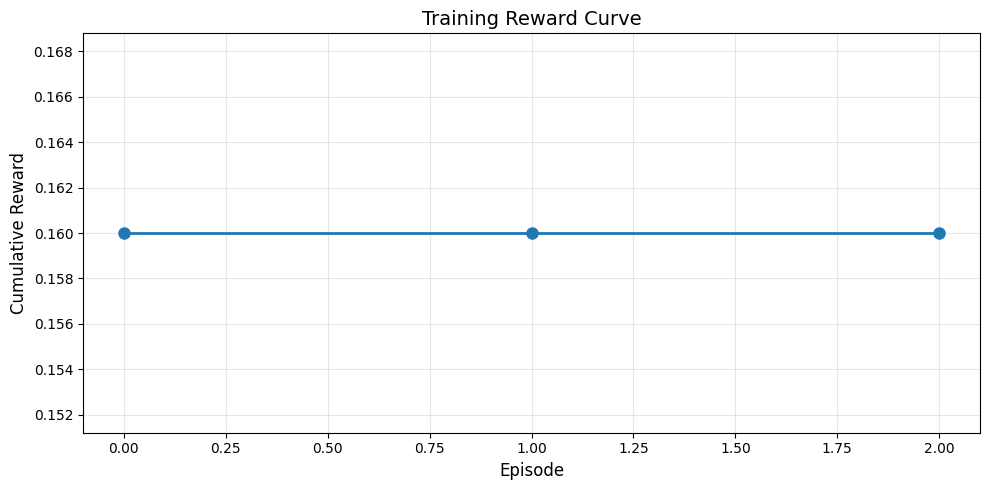

Reward curve saved to /content/reward_curve.png


In [61]:
plt.figure(figsize=(10, 5))
plt.plot(reward_history, marker="o", linewidth=2, markersize=8)
plt.title("Training Reward Curve", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Cumulative Reward", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
reward_plot_path = "/content/reward_curve.png"
plt.savefig(reward_plot_path, dpi=100)
plt.show()

print(f"Reward curve saved to {reward_plot_path}")

11. Run Inference Smoke Test on a Sample Observation


In [62]:
sample_observation = {
    "pending_emails": [
        {
            "id": "email_1",
            "sender": "alice@example.com",
            "subject": "Q2 Planning Meeting",
            "body": "Can we schedule a meeting for next week?",
        }
    ],
    "calendar_events": [],
    "current_step": 1,
}

smoke_prompt = f"""You are an executive assistant AI.

{format_observation_as_text(sample_observation)}

What action do you take?"""

inputs = tokenizer(smoke_prompt, return_tensors="pt")
if torch.cuda.is_available():
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=96,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

smoke_output = tokenizer.decode(generated[0], skip_special_tokens=True)
print(smoke_output)

c:\Users\sriab\OneDrive\Desktop\Projects\OfficeAgentEnv\.venv\Lib\site-packages\torch\utils\checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


You are an executive assistant AI.

PENDING EMAILS:
  1. From: alice@example.com, Subject: Q2 Planning Meeting

Current Step: 1

What action do you take? factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors


12. Notebook-Only Workflow


In [63]:
notebook_path = "train_officeagent_colab.ipynb"

print("This project uses the notebook as the primary training artifact.")
print(f"Notebook path: {notebook_path}")
print("No separate .py export is needed for this Colab workflow.")

This project uses the notebook as the primary training artifact.
Notebook path: train_officeagent_colab.ipynb
No separate .py export is needed for this Colab workflow.


13. Save Notebook Artifacts to Drive or Local Workspace


In [64]:
from pathlib import Path

artifact_dir = Path(OUTPUT_DIR)
artifact_dir.mkdir(parents=True, exist_ok=True)

artifacts = {
    "trained_model_dir": str(artifact_dir),
    "reward_plot": reward_plot_path if "reward_plot_path" in globals() else str(artifact_dir / "reward_curve.png"),
    "notebook_file": notebook_path,
}

for name, path in artifacts.items():
    print(f"{name}: {path}")

print("Notebook artifacts are ready for local workspace or mounted Drive sync.")

trained_model_dir: \content\officeagent-ft
reward_plot: /content/reward_curve.png
notebook_file: train_officeagent_colab.ipynb
Notebook artifacts are ready for local workspace or mounted Drive sync.
